# Vector Store CRUD Operations using OpenAI Embeddings and ChromaDB

## Objective

Convert text into embeddings and perform CRUD operations on a vector database using LangChain and ChromaDB.

### Operations

- Create
- Read
- Update
- Delete
- Similarity Search



# Import Required Libraries

In [7]:
import os

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document

# Create Embedding Model



In [9]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding Model Loaded Successfully")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3885.99it/s]


Embedding Model Loaded Successfully


# Convert Text into Embedding

In [10]:
text = "Artificial Intelligence is changing the world"

vector = embeddings.embed_query(text)

print("Vector Dimension:", len(vector))

Vector Dimension: 384


# Create Documents

In [11]:
from langchain_core.documents import Document

docs = [
    Document(
        page_content="Virat Kohli is a legendary batsman",
        metadata={"role":"batsman"}
    ),

    Document(
        page_content="MS Dhoni is Captain Cool",
        metadata={"role":"captain"}
    ),

    Document(
        page_content="Jasprit Bumrah is a fast bowler",
        metadata={"role":"bowler"}
    )
]

print("Documents Created")

Documents Created


# Create Chroma Vector Store

In [12]:
vector_store = Chroma(
    collection_name="cricket_players",
    embedding_function=embeddings,
    persist_directory="./chroma_db"
)

print("Vector Store Created")

C:\Users\Tirupati\AppData\Local\Temp\ipykernel_11896\1684900898.py:1: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store = Chroma(


Vector Store Created


# CREATE Operation
Add Documents into Vector Store

In [13]:
ids = vector_store.add_documents(docs)

print("Documents Added")
print(ids)

Documents Added
['15d1d669-38f7-4ca0-ba92-73a3f86db366', 'cee8464e-b76e-4687-b600-154739f2c7bf', '5f060997-5527-437c-bea2-9cb91062c60d']


# READ Operation
Retrieve All Documents

In [14]:
all_docs = vector_store.get()

all_docs

{'ids': ['15d1d669-38f7-4ca0-ba92-73a3f86db366',
  'cee8464e-b76e-4687-b600-154739f2c7bf',
  '5f060997-5527-437c-bea2-9cb91062c60d'],
 'embeddings': None,
 'documents': ['Virat Kohli is a legendary batsman',
  'MS Dhoni is Captain Cool',
  'Jasprit Bumrah is a fast bowler'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'role': 'batsman'}, {'role': 'captain'}, {'role': 'bowler'}]}

# Similarity Search

In [15]:
results = vector_store.similarity_search(
    "Who is a bowler?",
    k=2
)

for doc in results:
    print(doc.page_content)

Jasprit Bumrah is a fast bowler
Virat Kohli is a legendary batsman


# UPDATE Operation

In [16]:
updated_doc = Document(
    page_content="Jasprit Bumrah is the best death over specialist bowler",
    metadata={"role":"bowler"}
)

vector_store.update_document(
    document_id=ids[2],
    document=updated_doc
)

print("Document Updated")

Document Updated


# verify update 

In [17]:
result = vector_store.similarity_search(
    "death over specialist",
    k=1
)

print(result[0].page_content)

Jasprit Bumrah is the best death over specialist bowler


# DELETE Operation

In [18]:
vector_store.delete(
    ids=[ids[1]]
)

print("Document Deleted")

Document Deleted


In [19]:
# verify 

In [20]:
remaining_docs = vector_store.get()

remaining_docs

{'ids': ['15d1d669-38f7-4ca0-ba92-73a3f86db366',
  '5f060997-5527-437c-bea2-9cb91062c60d'],
 'embeddings': None,
 'documents': ['Virat Kohli is a legendary batsman',
  'Jasprit Bumrah is the best death over specialist bowler'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'role': 'batsman'}, {'role': 'bowler'}]}

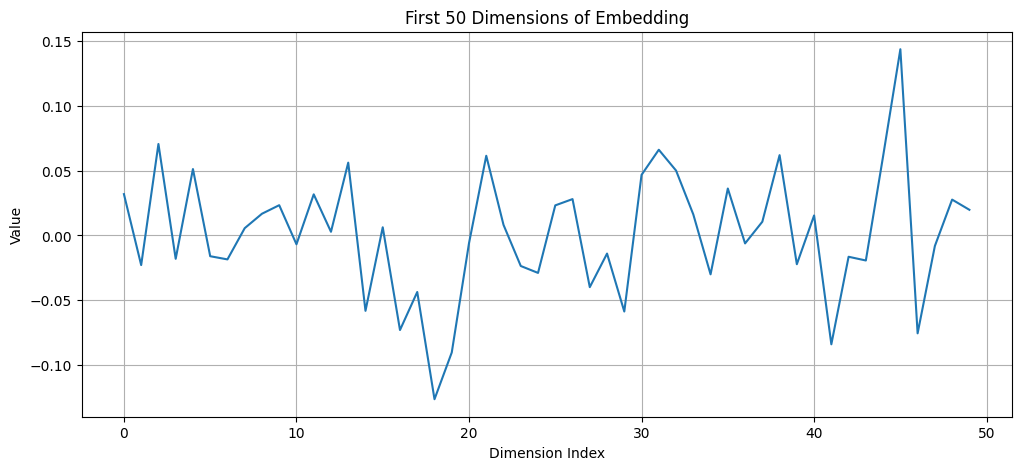

In [25]:
import matplotlib.pyplot as plt

text = "Artificial Intelligence is changing the world"

vector = embeddings.embed_query(text)

plt.figure(figsize=(12,5))
plt.plot(vector[:50])

plt.title("First 50 Dimensions of Embedding")
plt.xlabel("Dimension Index")
plt.ylabel("Value")
plt.grid(True)

plt.show()

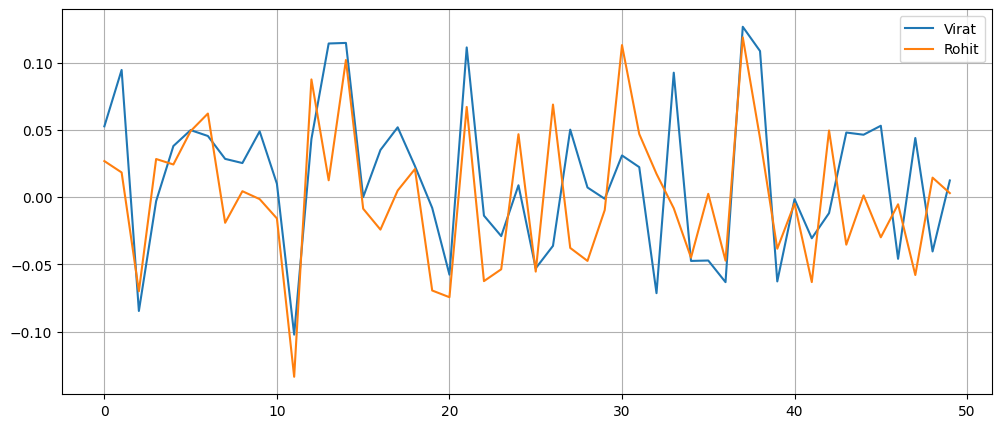

In [26]:
text1 = "Virat Kohli is a batsman"
text2 = "Rohit Sharma is a cricketer"

vec1 = embeddings.embed_query(text1)
vec2 = embeddings.embed_query(text2)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(vec1[:50], label="Virat")
plt.plot(vec2[:50], label="Rohit")

plt.legend()
plt.grid(True)
plt.show()